# Lesson 26A: Self-Supervised Contrastive Representation Learning (Theory)

## Introduction

Lesson 12A learned representations by RECONSTRUCTION: squeeze an image through a bottleneck, decode it back, and let pixel-space reconstruction error decide what the bottleneck is allowed to keep. That objective has a structural blind spot -- it is defined in pixel space, so it spends capacity on whatever is expensive to reproduce, and on real images that is precisely the nuisance detail (exact position, stroke thickness, background texture) a downstream task does not want. Lesson 5's PCA has the same character for the same reason: it keeps the directions of largest pixel VARIANCE, and pixel variance is not a measure of meaning.

This lesson derives the other route. Never reconstruct anything. Instead, define the representation by what it must treat as THE SAME: show the encoder two randomly augmented views of one image alongside views of other images, and ask it to pick its own partner out of the crowd. Solving that puzzle forces the encoder to discard everything the augmentation randomised and keep everything that identifies the source image -- and none of it needs a label.

The chain we build is short and each link is checked rather than asserted:

1. The classification game (one positive among $M$ candidates) has a Bayes-optimal solution that depends on the data ONLY through a density ratio -- verified exactly on a small discrete distribution.
2. Its cross-entropy, **InfoNCE**, is a lower bound on mutual information -- derived, and then verified numerically against a joint distribution whose mutual information we can compute in closed form.
3. **NT-Xent**, SimCLR's loss, is that same objective applied to a batch of augmented views -- implemented from scratch in PyTorch and validated against hand arithmetic and an independent plain-Python reference.
4. Without negatives the objective has a trivial global optimum -- a constant encoder -- which we drive a real network into on purpose, and measure.
5. The augmentation distribution IS the specification of invariance, which we make concrete by measuring which augmentations destroy class identity on MNIST.
6. A tiny end-to-end SimCLR run on cached MNIST, with the loss curve and a t-SNE of the learned features coloured by labels the training loop never saw.

## Table of Contents

1. [Required Libraries](#required-libraries)
2. [Pretext Tasks and the Idea of Invariance](#pretext)
3. [From Noise-Contrastive Estimation to InfoNCE](#infonce)
4. [The Mutual-Information Lower Bound](#mi-bound)
5. [Temperature and the Number of Negatives](#temperature)
6. [SimCLR and the NT-Xent Loss](#simclr)
7. [Why Representations Collapse Without Negatives](#collapse)
8. [Augmentations as the Specification of Invariance](#augmentations)
9. [End-to-End: SimCLR on an MNIST Subset](#mnist-run)
10. [Conclusion](#conclusion)

<a name="required-libraries"></a>
## Required Libraries

In [1]:
import math
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print(f"PyTorch {torch.__version__}")
print("Data: the MNIST copy already cached under notebooks/data -- nothing is downloaded.")

PyTorch 2.13.0+cu130
Data: the MNIST copy already cached under notebooks/data -- nothing is downloaded.


<a name="pretext"></a>
## Pretext Tasks and the Idea of Invariance

A **pretext task** is a supervised problem invented out of unlabelled data, solved not because anyone wants its answer but because solving it requires a useful representation as a by-product. The literature is a catalogue of them: predict the rotation applied to an image (Gidaris et al., 2018), predict the relative position of two patches (Doersch et al., 2015), solve a jigsaw of shuffled tiles (Noroozi & Favaro, 2016), colourise a greyscale image (Zhang et al., 2016), fill in a masked region (Pathak et al., 2016). Lesson 12A's autoencoder is itself a pretext task under this definition -- its invented problem is "reproduce your own input".

**Reconstruction's problem is that pixel distance is not a measure of sameness.** A reconstruction objective must reproduce the input exactly, which means it cannot be indifferent to anything -- position, thickness, and noise all cost it error, at a rate set by how many pixels they move. Before accepting that as a criticism, measure it: take MNIST digits and compare (a) the pixel distance between an image and a small shifted copy of ITSELF -- same digit, same instance, nuisance transform only -- against (b) the pixel distance between two DIFFERENT images that share a class, and (c) two images of different classes.

In [2]:
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())

N_IMAGES = 6000
X_img = train_dataset.data[:N_IMAGES].float().unsqueeze(1) / 255.0   # (N, 1, 28, 28) in [0, 1]
y_true = train_dataset.targets[:N_IMAGES]                            # held out; never used for training

print(f"Loaded {X_img.shape[0]} MNIST images of shape {tuple(X_img.shape[1:])}, "
      f"pixel range [{X_img.min():.1f}, {X_img.max():.1f}]")

flat = X_img.reshape(N_IMAGES, -1)


def shift(x, dx, dy):
    return torch.roll(x, shifts=(dy, dx), dims=(2, 3))


rng_np = np.random.default_rng(SEED)
n_probe = 800
idx_a = torch.from_numpy(rng_np.choice(N_IMAGES, n_probe, replace=False))

# (a) same instance, shifted a couple of pixels right and down
SHIFT_PX = 2
d_self_shift = ((flat[idx_a]
                 - shift(X_img[idx_a], SHIFT_PX, SHIFT_PX).reshape(n_probe, -1)) ** 2).mean(dim=1)

# (b) different instance, SAME class  (c) different instance, DIFFERENT class
by_class = {c: np.flatnonzero(y_true.numpy() == c) for c in range(10)}
partner_same, partner_diff = [], []
for i in idx_a.tolist():
    c = int(y_true[i])
    j = i
    while j == i:
        j = int(rng_np.choice(by_class[c]))
    partner_same.append(j)
    c2 = c
    while c2 == c:
        c2 = int(rng_np.integers(10))
    partner_diff.append(int(rng_np.choice(by_class[c2])))

d_same_class = ((flat[idx_a] - flat[torch.tensor(partner_same)]) ** 2).mean(dim=1)
d_diff_class = ((flat[idx_a] - flat[torch.tensor(partner_diff)]) ** 2).mean(dim=1)

print(f"\nMean per-pixel squared distance over {n_probe} probes:")
print(f"  (a) same image, shifted by ({SHIFT_PX}, {SHIFT_PX}) : {d_self_shift.mean():.5f}")
print(f"  (b) different image, same digit   : {d_same_class.mean():.5f}")
print(f"  (c) different image, other digit  : {d_diff_class.mean():.5f}")

frac = (d_self_shift > d_same_class).float().mean().item()
frac_diff = (d_self_shift > d_diff_class).float().mean().item()
print(f"\nA {SHIFT_PX}-pixel shift of the SAME image is farther in pixel space than a different image "
      f"of the same digit for {frac:.1%} of probes,")
print(f"and farther than a different image of a DIFFERENT digit for {frac_diff:.1%} of probes.")
print("Pixel distance therefore cannot express 'these two are the same thing' -- so an objective "
      "built only on pixel distance has no way to learn it.")

Loaded 6000 MNIST images of shape (1, 28, 28), pixel range [0.0, 1.0]



Mean per-pixel squared distance over 800 probes:
  (a) same image, shifted by (2, 2) : 0.14410
  (b) different image, same digit   : 0.10770
  (c) different image, other digit  : 0.14134

A 2-pixel shift of the SAME image is farther in pixel space than a different image of the same digit for 80.4% of probes,
and farther than a different image of a DIFFERENT digit for 55.0% of probes.
Pixel distance therefore cannot express 'these two are the same thing' -- so an objective built only on pixel distance has no way to learn it.


**Contrastive learning replaces the yardstick instead of improving the decoder.** Rather than asking the representation to reproduce the input, it asks the representation to satisfy a RELATION: two views of the same source image must be close, views of different source images must be far. Nothing in that statement mentions pixels. Whatever transformation is used to produce the two views is thereby declared irrelevant, and everything that survives it is declared to be the content.

That single change is what makes the objective's output a *representation* rather than a *compression*. We now derive the loss that expresses the relation.

<a name="infonce"></a>
## From Noise-Contrastive Estimation to InfoNCE

**Noise-contrastive estimation** (Gutmann & Hyvärinen, 2010) is the trick of replacing an intractable density-estimation problem with a tractable classification problem: rather than model $p(x)$, learn to tell real samples apart from noise samples, and read the density off the classifier. Lesson 25A already used the binary form of this idea -- word2vec's negative sampling is NCE with $k$ noise words per positive, which turned an $O(|V|)$ softmax into $O(k)$ binary decisions.

**InfoNCE** (van den Oord, Li & Vinyals, 2018, *Representation Learning with Contrastive Predictive Coding*) is the multi-class version, and it is set up as a game.

**The game.** Fix a context $c$ -- for our purposes, one view of an image. Draw one **positive** $x_1 \sim p(x \mid c)$ (another view of the same image) and $K$ **negatives** $x_2, \dots, x_M \sim p(x)$ drawn independently from the marginal, so there are

$$M = K + 1 \quad \text{candidates in total.}$$

Shuffle them. The learner sees the set and the context, and must say which candidate is the positive.

**The Bayes-optimal answer depends on the data only through a density ratio.** Let $I$ be the index of the positive. The probability that the positive is at index $i$, given that exactly one candidate came from $p(\cdot \mid c)$ and the rest from $p(\cdot)$, is

$$p(I = i \mid x_{1:M}, c) \;=\; \frac{p(x_i \mid c)\prod_{l \neq i} p(x_l)}{\sum_{j=1}^{M} p(x_j \mid c)\prod_{l \neq j} p(x_l)}.$$

Divide numerator and denominator by $\prod_{l=1}^{M} p(x_l)$ -- a quantity that does not depend on $i$ or $j$, so it cancels cleanly -- and every product collapses:

$$p(I = i \mid x_{1:M}, c) \;=\; \frac{\dfrac{p(x_i \mid c)}{p(x_i)}}{\displaystyle\sum_{j=1}^{M} \dfrac{p(x_j \mid c)}{p(x_j)}} \;=\; \frac{r(x_i, c)}{\sum_{j} r(x_j, c)}, \qquad r(x,c) \equiv \frac{p(x\mid c)}{p(x)}.$$

This is the load-bearing step of the whole subject. The optimal classifier never needs $p(x \mid c)$ or $p(x)$ separately, only their **ratio**, and only **up to a constant** -- any $f = \alpha \cdot r$ gives the same softmax. That is exactly why an unnormalised similarity score $\exp(\text{sim}(z_x, z_c)/\tau)$, which is not a density and integrates to nothing in particular, is a legitimate stand-in for the optimal critic.

**The loss.** InfoNCE is the cross-entropy of that classification, for a learned critic $f > 0$:

$$\mathcal{L}_M \;=\; -\,\mathbb{E}\left[\log \frac{f(x_1, c)}{\sum_{j=1}^{M} f(x_j, c)}\right], \qquad x_1 \text{ the positive},$$

and by the identity above its minimiser over all functions $f$ is $f \propto r$. Check the collapse of the products numerically before building on it.

In [3]:
# A small discrete joint p(c, x) we can compute everything about exactly.
C_SIZE, V_SIZE, ALPHA = 8, 8, 0.35
p_c = np.full(C_SIZE, 1.0 / C_SIZE)
P_x_given_c = np.full((C_SIZE, V_SIZE), ALPHA / (V_SIZE - 1))
np.fill_diagonal(P_x_given_c, 1.0 - ALPHA)
p_x = p_c @ P_x_given_c
ratio = P_x_given_c / p_x[None, :]          # r(x, c), indexed [c, x]

# Brute-force the posterior from its ORIGINAL product form, for one concrete candidate set.
c0 = 3
cand = [3, 0, 5, 6]                          # candidate symbols; index 0 is the positive
prod_form = np.array([P_x_given_c[c0, cand[i]] * np.prod([p_x[cand[l]] for l in range(len(cand)) if l != i])
                      for i in range(len(cand))])
prod_form /= prod_form.sum()

ratio_form = np.array([ratio[c0, x] for x in cand])
ratio_form /= ratio_form.sum()

print("posterior from the product form :", np.round(prod_form, 8))
print("posterior from the density ratio:", np.round(ratio_form, 8))
print(f"max abs difference              : {np.abs(prod_form - ratio_form).max():.2e}")
assert np.allclose(prod_form, ratio_form), "density-ratio collapse failed"

# ...and it is invariant to rescaling the critic, which is why an unnormalised score works.
scaled = 17.3 * ratio_form
scaled = scaled / scaled.sum()
print(f"same posterior after scaling the critic by 17.3: {np.abs(scaled - ratio_form).max():.2e}")
print("\nThe two forms agree exactly, and the answer is unchanged by an arbitrary positive scale factor.")

posterior from the product form : [0.8125 0.0625 0.0625 0.0625]
posterior from the density ratio: [0.8125 0.0625 0.0625 0.0625]
max abs difference              : 0.00e+00
same posterior after scaling the critic by 17.3: 0.00e+00

The two forms agree exactly, and the answer is unchanged by an arbitrary positive scale factor.


<a name="mi-bound"></a>
## The Mutual-Information Lower Bound

Minimising $\mathcal{L}_M$ maximises a **lower bound** on the mutual information $I(x; c)$. Deriving it takes three lines; understanding what the bound does *not* say takes rather longer, and matters more.

**Derivation.** Substitute the optimal critic $f = r$ and divide the fraction through by $r(x_1, c)$:

$$\mathcal{L}_M \;=\; -\,\mathbb{E}\!\left[\log \frac{r_1}{r_1 + \sum_{j=2}^{M} r_j}\right] \;=\; \mathbb{E}\!\left[\log\!\left(1 + \frac{1}{r_1}\sum_{j=2}^{M} r_j\right)\right], \qquad r_j \equiv r(x_j, c).$$

The negatives are drawn from the marginal, and the ratio has expectation exactly one under the marginal:

$$\mathbb{E}_{x \sim p(x)}\big[r(x, c)\big] \;=\; \sum_x p(x)\,\frac{p(x \mid c)}{p(x)} \;=\; \sum_x p(x \mid c) \;=\; 1 .$$

So $\sum_{j=2}^{M} r_j$ has mean exactly $K$, and by the law of large numbers concentrates there as $K$ grows. Replacing the sum by its mean and then dropping the $1+$ (which only decreases the bracket, so the inequality is safe):

$$\mathcal{L}_M \;\approx\; \mathbb{E}\!\left[\log\!\left(1 + \frac{K}{r_1}\right)\right] \;\ge\; \mathbb{E}\!\left[\log \frac{K}{r_1}\right] \;=\; \log K \;-\; \mathbb{E}\big[\log r(x_1, c)\big] \;=\; \log K - I(x; c),$$

because $\mathbb{E}_{(x,c) \sim p(x,c)}\!\left[\log \frac{p(x \mid c)}{p(x)}\right]$ is the definition of mutual information. Rearranged:

$$\boxed{\;I(x; c) \;\ge\; \log K \;-\; \mathcal{L}_M\;}$$

The form usually quoted writes $\log M$ (the candidate count) rather than $\log K$ (the negative count). The two differ by $\log\frac{M}{K} = \log(1 + 1/K)$, which is under $0.01$ nats once $K \ge 100$; the $\log M$ version is the tighter of the two, so verifying *it* numerically also verifies the looser one. That is what the next cell does, since the derivation's law-of-large-numbers step is an approximation at finite $K$ and deserves a check rather than trust.

**What the bound does and does not say.**

- **It is a bound, not a measurement.** InfoNCE does not compute mutual information. A lower InfoNCE loss certifies a higher *lower bound*; it does not establish that the true mutual information rose.
- **The bound is capped at $\log M$.** Since $\mathcal{L}_M = -\log(\text{a probability}) \ge 0$ always, $\log M - \mathcal{L}_M \le \log M$ no matter how good the encoder. Certifying $I$ nats requires $M \ge e^{I}$ candidates -- **exponentially many negatives in the information you want to certify.** This is the honest reason batch size is a first-class hyperparameter in SimCLR and why MoCo (He et al., 2020) maintains a queue of negatives instead of paying for a huge batch.
- **Limiting case $K = 0$ ($M = 1$).** The softmax has one term, so $\mathcal{L}_1 = -\log 1 = 0$ exactly, and the bound reads $I \ge \log 1 - 0 = 0$. Nothing is certified, because a game with one candidate is won by any answer. This is the collapse story of the next-but-one section, seen from the bound's side.
- **Limiting case $K \to \infty$.** The ceiling $\log M$ diverges and the law-of-large-numbers step becomes exact, so the *bound's* slack vanishes -- but only if the critic is near-optimal. A poor critic makes $\mathcal{L}_M$ large and the bound useless at any $K$.
- **Maximising mutual information is not, by itself, an explanation.** Tschannen et al. (2020) construct encoders with high mutual information and useless representations; the architecture of the critic and the choice of augmentation do more of the work than the bound's value does. The bound tells us the objective is not arbitrary. It does not tell us the objective is sufficient.

**One caution about the verification itself.** $\mathcal{L}_M$ is an expectation, and the cell below estimates it by Monte Carlo, so each row carries sampling error. At large $M$ the bound gets so close to the truth that the *estimate* lands on either side of it -- with the sample size used here, a bare `bound <= I` test on the largest-$M$ row fails for roughly half of all random seeds, not because the theorem is wrong but because the estimator's noise exceeds the remaining slack. So the table reports a standard error with every entry and the assertions are written against that error. This is worth noticing rather than hiding: a verification that would pass or fail on the choice of seed is not a verification, and the fix is to quote the error bar, not to hunt for a seed that passes.

In [4]:
# Exact mutual information of the joint defined above (nats).
mi_true = sum(p_c[c] * P_x_given_c[c, x] * math.log(P_x_given_c[c, x] / p_x[x])
              for c in range(C_SIZE) for x in range(V_SIZE) if P_x_given_c[c, x] > 0)

cum_cond = np.cumsum(P_x_given_c, axis=1)
cum_marg = np.cumsum(p_x)


N_TRIALS = 60000


def infonce_loss(M, critic, n_trials=N_TRIALS, seed=1):
    'Monte-Carlo InfoNCE loss with its standard error: 1 positive from p(x|c), M-1 from p(x).'
    r = np.random.default_rng(seed)
    cs = r.integers(0, C_SIZE, size=n_trials)                       # p(c) uniform here
    pos = np.array([np.searchsorted(cum_cond[c], u) for c, u in zip(cs, r.random(n_trials))])
    negs = np.searchsorted(cum_marg, r.random((n_trials, M - 1)))
    f_pos = critic[cs, pos]
    f_neg = critic[cs[:, None], negs]
    per_sample = -np.log(f_pos / (f_pos + f_neg.sum(axis=1)))
    return float(per_sample.mean()), float(per_sample.std(ddof=1) / math.sqrt(n_trials))


Ms = [2, 4, 8, 16, 64, 256, 1024]
rows = [(M, *infonce_loss(M, ratio)) for M in Ms]

print(f"True mutual information I(x; c) = {mi_true:.4f} nats "
      f"(the maximum possible here is log {V_SIZE} = {math.log(V_SIZE):.4f})")
print(f"Estimated from {N_TRIALS} Monte-Carlo draws per row; +/- is one standard error.\n")
print(f"{'M':>6} {'K = M-1':>8} {'loss L_M':>10} {'log M - L_M':>14} {'ceiling log M':>14} "
      f"{'slack under I':>15}")
for M, L, se in rows:
    bound = math.log(M) - L
    print(f"{M:>6} {M-1:>8} {L:>10.4f} {bound:>8.4f} +/-{se:.4f} {math.log(M):>14.4f} "
          f"{mi_true - bound:>+9.4f} ({(mi_true - bound) / se:>+5.1f} SE)")

bounds = [math.log(M) - L for M, L, _ in rows]
ses = [s for _, _, s in rows]

# The theorem bounds the EXPECTATION. A finite-sample estimate fluctuates around it, so both
# checks are written against Monte-Carlo error rather than exactly -- see the markdown above.
assert all(b <= mi_true + 4 * s for b, s in zip(bounds, ses)), \
    "bound exceeded the true MI by more than Monte-Carlo error"
assert all(b2 >= b1 - 3 * s for b1, b2, s in zip(bounds, bounds[1:], ses[1:])), \
    "bound did not tighten with M"

small, large = bounds[0], bounds[-1]
print(f"\nNo entry exceeds the true value by more than Monte-Carlo error, and the bound tightens "
      f"steadily with M: {small:.4f} nats at M={Ms[0]} to {large:.4f} nats at M={Ms[-1]}, "
      f"closing {large / mi_true:.2%} of the true {mi_true:.4f} nats.")
print(f"At the largest M the remaining slack is {mi_true - large:+.4f} nats against a standard error of "
      f"{ses[-1]:.4f} -- {abs(mi_true - large) / ses[-1]:.1f} standard errors, i.e. statistically "
      f"indistinguishable from the truth. That IS what a tight bound looks like, and it is also why the "
      f"check above is written against the error bar rather than as a bare inequality.")
print(f"At M={Ms[0]} the ceiling log M = {math.log(Ms[0]):.4f} is itself below I = {mi_true:.4f}: "
      f"with that few candidates the bound CANNOT reach the truth however good the critic is.")

# A deliberately mis-scaled critic: still a valid bound, just a worse one.
bad_L, bad_se = infonce_loss(256, ratio ** 0.25)
bad_bound = math.log(256) - bad_L
good_bound = math.log(256) - rows[-2][1]
print(f"\nWith a deliberately blunted critic r^0.25 at M=256 the bound falls to {bad_bound:.4f} nats "
      f"(vs {good_bound:.4f} for the optimal critic) -- still a valid lower bound, just a weaker one, "
      f"and the gap of {good_bound - bad_bound:.4f} nats is {(good_bound - bad_bound) / bad_se:.0f} "
      f"standard errors wide, so it is a real effect rather than sampling noise. "
      f"A bad critic loses certification; it never breaks the inequality.")

True mutual information I(x; c) = 0.7509 nats (the maximum possible here is log 8 = 2.0794)
Estimated from 60000 Monte-Carlo draws per row; +/- is one standard error.

     M  K = M-1   loss L_M    log M - L_M  ceiling log M   slack under I
     2        1     0.4260   0.2671 +/-0.0023         0.6931   +0.4838 (+211.5 SE)
     4        3     0.9221   0.4642 +/-0.0034         1.3863   +0.2867 (+83.2 SE)
     8        7     1.4822   0.5973 +/-0.0042         2.0794   +0.1537 (+36.5 SE)
    16       15     2.1003   0.6723 +/-0.0046         2.7726   +0.0787 (+17.0 SE)
    64       63     3.4276   0.7313 +/-0.0049         4.1589   +0.0196 ( +4.0 SE)
   256      255     4.7975   0.7477 +/-0.0050         5.5452   +0.0032 ( +0.6 SE)
  1024     1023     6.1809   0.7506 +/-0.0050         6.9315   +0.0003 ( +0.1 SE)

No entry exceeds the true value by more than Monte-Carlo error, and the bound tightens steadily with M: 0.2671 nats at M=2 to 0.7506 nats at M=1024, closing 99.95% of the true 0.7509 


With a deliberately blunted critic r^0.25 at M=256 the bound falls to 0.3092 nats (vs 0.7477 for the optimal critic) -- still a valid lower bound, just a weaker one, and the gap of 0.4385 nats is 353 standard errors wide, so it is a real effect rather than sampling noise. A bad critic loses certification; it never breaks the inequality.


<a name="temperature"></a>
## Temperature and the Number of Negatives

In practice the critic is not a learned density ratio but a bounded similarity:

$$f(x, c) \;=\; \exp\!\big(\text{sim}(z_x, z_c) / \tau\big), \qquad \text{sim}(u, v) = \frac{u^\top v}{\lVert u\rVert\,\lVert v\rVert} \in [-1, 1].$$

Because cosine similarity is bounded, the critic's expressible range of log-ratios is bounded too: $\log f$ spans only $[-1/\tau,\, 1/\tau]$. **The temperature is the dynamic range the critic is allowed to express.** Two consequences follow, and both are worth checking numerically rather than believing.

**1. $\tau$ sets how sharply the loss attends to the hardest negatives.** The softmax over $\{s_k/\tau\}$ concentrates on the largest $s_k$ as $\tau \to 0$ and flattens toward uniform as $\tau \to \infty$.

**2. $\tau$ scales the gradient.** With $\ell = -s_{\text{pos}}/\tau + \log\sum_k e^{s_k/\tau}$ and $p_k$ the softmax weights,

$$\frac{\partial \ell}{\partial s_k} \;=\; \frac{1}{\tau}\big(p_k - \mathbb{1}[k = \text{pos}]\big),$$

so halving $\tau$ both sharpens the distribution and doubles the gradient scale. In particular $\partial \ell / \partial s_{\text{pos}} = (p_{\text{pos}} - 1)/\tau \le 0$: **the loss is non-increasing in the positive's similarity, holding every other similarity fixed** -- a fact we will verify twice, once here and once on the real loss.

There is no free lunch in either direction, and the next cell makes the trade explicit by running two fixed similarity vectors: one where the positive is already the best match, and one where a hard negative beats it.

In [5]:
def softmax_np(s):
    e = np.exp(s - s.max())
    return e / e.sum()


# Index 0 is the positive in both vectors. Only the ranking differs.
sims_easy = np.array([0.60, 0.55, 0.20, -0.10, -0.40])   # positive already ranks first
sims_hard = np.array([0.40, 0.75, 0.20, -0.10, -0.40])   # a hard negative outranks the positive
taus = [0.05, 0.1, 0.3, 1.0, 3.0]

for name, sims in [("positive ranks FIRST", sims_easy), ("a hard negative OUTRANKS it", sims_hard)]:
    print(f"{name}   sims = [{', '.join(f'{v:+.2f}' for v in sims)}]  (index 0 is the positive)")
    print(f"  {'tau':>6} {'p_pos':>8} {'loss':>8} {'entropy':>9} {'top-neg share':>14} {'|dl/ds_pos|':>12}")
    for t in taus:
        p = softmax_np(sims / t)
        neg = p[1:] / p[1:].sum()
        ent = float(-(p * np.log(p)).sum())
        print(f"  {t:>6} {p[0]:>8.4f} {-math.log(p[0]):>8.4f} {ent:>9.4f} "
              f"{neg.max():>14.4f} {abs(p[0]-1)/t:>12.4f}")
    print()

ent_lo = float(-(softmax_np(sims_easy / taus[0]) * np.log(softmax_np(sims_easy / taus[0]))).sum())
ent_hi = float(-(softmax_np(sims_easy / taus[-1]) * np.log(softmax_np(sims_easy / taus[-1]))).sum())
share_lo = (lambda p: (p[1:] / p[1:].sum()).max())(softmax_np(sims_easy / taus[0]))
share_hi = (lambda p: (p[1:] / p[1:].sum()).max())(softmax_np(sims_easy / taus[-1]))
print(f"Sharpening is measured, not assumed: over tau {taus[0]} -> {taus[-1]} the softmax entropy rises "
      f"{ent_lo:.4f} -> {ent_hi:.4f} nats, and the single hardest negative's share of the negative mass "
      f"falls {share_lo:.1%} -> {share_hi:.1%}.")

loss_hard_lo = -math.log(softmax_np(sims_hard / taus[0])[0])
loss_hard_hi = -math.log(softmax_np(sims_hard / taus[-1])[0])
print(f"\nLower is NOT simply better. When a hard negative outranks the positive, shrinking tau "
      f"{taus[-1]} -> {taus[0]} drives the loss {loss_hard_hi:.4f} -> {loss_hard_lo:.4f} -- the same "
      f"sharpening that concentrates useful gradient on hard negatives also makes a single mislabelled "
      f"or genuinely ambiguous pair dominate the batch.")

# Verify the gradient formula against autograd rather than trusting the algebra.
s_t = torch.tensor(sims_easy, requires_grad=True)
tau_chk = 0.3
loss_t = -torch.log_softmax(s_t / tau_chk, dim=0)[0]
loss_t.backward()
p_chk = softmax_np(sims_easy / tau_chk)
analytic = (p_chk - np.eye(len(sims_easy))[0]) / tau_chk
print(f"\nGradient check at tau={tau_chk}: max |autograd - analytic| = "
      f"{np.abs(s_t.grad.numpy() - analytic).max():.2e}")
assert np.allclose(s_t.grad.numpy(), analytic, atol=1e-6)

positive ranks FIRST   sims = [+0.60, +0.55, +0.20, -0.10, -0.40]  (index 0 is the positive)
     tau    p_pos     loss   entropy  top-neg share  |dl/ds_pos|
    0.05   0.7309   0.3135    0.5844         0.9991       5.3824
     0.1   0.6151   0.4860    0.7218         0.9692       3.8492
     0.3   0.4459   0.8077    1.1812         0.6811       1.8470
     1.0   0.2869   1.2488    1.5446         0.3826       0.7131
     3.0   0.2290   1.4741    1.6016         0.2921       0.2570

a hard negative OUTRANKS it   sims = [+0.40, +0.75, +0.20, -0.10, -0.40]  (index 0 is the positive)
     tau    p_pos     loss   entropy  top-neg share  |dl/ds_pos|
    0.05   0.0009   7.0009    0.0075         1.0000      19.9818
     0.1   0.0292   3.5339    0.1596         0.9957       9.7081
     0.3   0.2007   1.6060    1.0232         0.8062       2.6644
     1.0   0.2329   1.4571    1.5340         0.4308       0.7671
     3.0   0.2141   1.5415    1.6007         0.3061       0.2620

Sharpening is measured, n

<a name="simclr"></a>
## SimCLR and the NT-Xent Loss

**SimCLR** (Chen, Kornblith, Norouzi & Hinton, 2020) is InfoNCE with the context and the positive both produced by augmentation, and everything else in the batch used as negatives. Four components, no more:

1. A stochastic augmentation $t \sim \mathcal{T}$. Each image in the batch is augmented **twice**, giving two views of the same source.
2. An **encoder** $g$ (a CNN here) producing the representation $h = g(\tilde{x})$ -- the thing you keep and use downstream.
3. A small **projection head** $q$ (an MLP) producing $z = q(h)$ -- the thing the loss is computed on, and then thrown away. SimCLR's own ablation found $h$ transfers better than $z$, so the head exists to absorb the invariances the loss demands without forcing the representation to discard them.
4. The **NT-Xent** loss on the $z$'s.

**The loss, written out.** A batch of $N$ images augmented twice gives $2N$ views $z_1, \dots, z_{2N}$, indexed so that $z_{2k-1}$ and $z_{2k}$ are the two views of image $k$. For a positive pair $(i, j)$:

$$\ell_{i,j} \;=\; -\log \frac{\exp\big(\text{sim}(z_i, z_j)/\tau\big)}{\displaystyle\sum_{k=1}^{2N} \mathbb{1}_{[k \neq i]} \exp\big(\text{sim}(z_i, z_k)/\tau\big)}$$

and the batch loss is the mean over all $2N$ anchors, each view taking its turn:

$$\mathcal{L} \;=\; \frac{1}{2N}\sum_{k=1}^{N}\Big[\ell_{2k-1,\,2k} \;+\; \ell_{2k,\,2k-1}\Big].$$

Three properties are easy to state wrongly, so state them carefully:

- **It is asymmetric.** $\ell_{i,j} \neq \ell_{j,i}$ in general, because the denominator is anchored at $i$ and excludes only $i$ itself. This is exactly why the sum runs over both orderings of every pair rather than over the $N$ pairs once.
- **Both views of every other image are negatives.** For an anchor from image $a$, the denominator contains one positive and $2N - 2$ negatives -- not $N-1$. The other view of image $b \neq a$ is just as much a negative as the first.
- **So $M = 2N - 1$**, and the previous section's ceiling applies directly: this loss can certify at most $\log(2N - 1)$ nats, and its chance-level value for an uninformative encoder is that same $\log(2N-1)$. Doubling the batch buys $\log 2 \approx 0.69$ extra nats of ceiling.

Three implementations follow, deliberately sharing no code with each other, so that agreement between them is evidence rather than a tautology:

1. `nt_xent_reference` -- plain Python: lists, `math.exp`, explicit loops, no tensors and no broadcasting.
2. `nt_xent_manual` -- from scratch in tensors: build the similarity matrix, mask the diagonal, and take the log-sum-exp by hand.
3. `nt_xent` -- the production route: the same masked similarity matrix handed to PyTorch's own `F.cross_entropy`, which is what the training loop later uses.

They are then checked against a closed-form value computed by hand, and against each other on random batches at several shapes and temperatures.

In [6]:
# ---- Reference: plain Python. No tensor ops, no broadcasting, no shared code path. ----
def cosine_py(u, v):
    nu = math.sqrt(sum(a * a for a in u))
    nv = math.sqrt(sum(b * b for b in v))
    return sum(a * b for a, b in zip(u, v)) / (nu * nv)


def nt_xent_reference(rows, tau):
    'rows: list of 2N lists; rows[2k] and rows[2k+1] are the two views of image k.'
    n2 = len(rows)
    total = 0.0
    for i in range(n2):
        j = i + 1 if i % 2 == 0 else i - 1              # this anchor's positive
        numer = math.exp(cosine_py(rows[i], rows[j]) / tau)
        denom = sum(math.exp(cosine_py(rows[i], rows[k]) / tau) for k in range(n2) if k != i)
        total += -math.log(numer / denom)
    return total / n2


# ---- From scratch, in tensors: similarity matrix, masked diagonal, log-sum-exp by hand. ----
def masked_similarity(z, tau):
    'Shared setup: unit-normalise, take all pairwise cosines / tau, block each row self-match.'
    n2 = z.shape[0]
    z = F.normalize(z, dim=1)                                     # cosine == dot on unit vectors
    sim = (z @ z.t()) / tau                                       # (2N, 2N)
    return sim.masked_fill(torch.eye(n2, dtype=torch.bool, device=z.device), float('-inf'))


def positive_index(n2, device=None):
    'Anchor i pairs with i^1: 0<->1, 2<->3, ...'
    return torch.arange(n2, device=device) ^ 1


def nt_xent_manual(z, tau):
    'From scratch: -log( exp(s_pos) / sum_k exp(s_k) ), log-sum-exp written out, mean over anchors.'
    sim = masked_similarity(z, tau)
    pos = sim.gather(1, positive_index(sim.shape[0], z.device).unsqueeze(1)).squeeze(1)
    shift_max = sim.max(dim=1, keepdim=True).values                       # stability shift
    lse = shift_max.squeeze(1) + torch.log(torch.exp(sim - shift_max).sum(dim=1))
    return (lse - pos).mean()


# ---- Production route: the same matrix handed to PyTorch's own cross-entropy. ----
def nt_xent(z, tau):
    'z: (2N, d) with rows 2k / 2k+1 a positive pair. Returns the scalar batch loss.'
    sim = masked_similarity(z, tau)
    return F.cross_entropy(sim, positive_index(sim.shape[0], z.device))   # mean over the 2N anchors


# ---- Check 1: closed-form hand arithmetic. ----
# Two pairs at right angles: z1 = z2 = (1,0), z3 = z4 = (0,1), tau = 1.
# Every anchor sees sim(positive) = 1 and two negatives at sim = 0, so by symmetry
#     L = -log( e^1 / (e^1 + e^0 + e^0) ) = log(1 + 2/e).
Z_hand = torch.tensor([[1., 0.], [1., 0.], [0., 1.], [0., 1.]])
closed_form = math.log(1.0 + 2.0 / math.e)
hand_results = {
    'closed form  log(1 + 2/e)': closed_form,
    'plain-Python reference   ': nt_xent_reference(Z_hand.tolist(), 1.0),
    'from-scratch tensors     ': nt_xent_manual(Z_hand, 1.0).item(),
    'production F.cross_entropy': nt_xent(Z_hand, 1.0).item(),
}
print("Check 1 -- hand arithmetic on 2 orthogonal pairs, tau = 1")
for label, val in hand_results.items():
    print(f"  {label} = {val:.10f}")
print(f"  max deviation from the closed form = "
      f"{max(abs(v - closed_form) for v in hand_results.values()):.2e}")
assert max(abs(v - closed_form) for v in hand_results.values()) < 1e-6

# ---- Check 2: all three agree on random batches at several shapes and temperatures. ----
print(f"\nCheck 2 -- all three implementations on random batches")
print(f"  {'shape':<24} {'plain Python':>14} {'from scratch':>14} {'F.cross_entropy':>16} {'spread':>9}")
torch.manual_seed(SEED)
worst_spread = 0.0
for N_b, d_b, tau_b in [(3, 4, 0.5), (5, 8, 0.1), (2, 2, 1.3), (8, 16, 0.07)]:
    zb = torch.randn(2 * N_b, d_b)
    trio = [nt_xent_reference(zb.tolist(), tau_b), nt_xent_manual(zb, tau_b).item(),
            nt_xent(zb, tau_b).item()]
    spread = max(trio) - min(trio)
    worst_spread = max(worst_spread, spread)
    print(f"  N={N_b:<2} d={d_b:<2} tau={tau_b:<12} {trio[0]:>14.8f} {trio[1]:>14.8f} "
          f"{trio[2]:>16.8f} {spread:>9.1e}")
print(f"  worst spread across all shapes: {worst_spread:.2e} "
      f"(float32 round-off; the plain-Python reference runs in float64)")
assert worst_spread < 1e-4

Check 1 -- hand arithmetic on 2 orthogonal pairs, tau = 1
  closed form  log(1 + 2/e) = 0.5514447139
  plain-Python reference    = 0.5514447139
  from-scratch tensors      = 0.5514447093
  production F.cross_entropy = 0.5514446497
  max deviation from the closed form = 6.42e-08

Check 2 -- all three implementations on random batches
  shape                      plain Python   from scratch  F.cross_entropy    spread
  N=3  d=4  tau=0.5              1.88578771     1.88578784       1.88578796   2.6e-07
  N=5  d=8  tau=0.1              5.52312618     5.52312517       5.52312565   1.0e-06
  N=2  d=2  tau=1.3              1.01858650     1.01858664       1.01858652   1.3e-07
  N=8  d=16 tau=0.07             5.99231741     5.99231768       5.99231720   4.8e-07
  worst spread across all shapes: 1.01e-06 (float32 round-off; the plain-Python reference runs in float64)


### Two properties of the loss, checked rather than asserted

**Monotonicity in the positive's similarity.** The gradient derived above gives $\partial \ell/\partial s_{\text{pos}} = (p_{\text{pos}} - 1)/\tau \le 0$, so the per-anchor loss falls as the positive's similarity rises **with every other similarity held fixed**. That last clause is not a technicality: in a real batch you cannot hold the rest fixed, because moving one embedding changes its similarity to every anchor at once -- it is simultaneously somebody's positive and everybody else's negative. The cell below shows both facts: the strict monotonicity when the other scores really are frozen, and the non-monotonicity that appears the moment you rotate an actual embedding instead.

**The collapsed batch is the WORST case, exactly.** If all $2N$ embeddings point the same way, every similarity in the denominator equals the positive's, so the softmax is uniform over its $2N-1$ terms and

$$\ell_i \;=\; -\log \frac{e^{1/\tau}}{(2N-1)\,e^{1/\tau}} \;=\; \log(2N-1) \quad \text{for every } i,$$

independent of $\tau$. That is the chance-level value and the maximum the loss attains -- the exact opposite of the attract-only objective in the next section, whose global *minimum* is collapse.

In [7]:
# --- Monotonicity with everything else genuinely fixed: operate on the score vector. ---
frozen_negs = np.array([0.3, 0.1, -0.2])
print(f"Per-anchor loss as the positive's similarity rises, negatives FROZEN at "
      f"{[round(float(v), 2) for v in frozen_negs]}:")
prev, mono = None, True
for s_pos in [-0.5, -0.2, 0.0, 0.2, 0.5, 0.8, 1.0]:
    scores = np.concatenate([[s_pos], frozen_negs])
    loss_v = -math.log(softmax_np(scores / 0.5)[0])
    flag = "" if prev is None else ("  (down)" if loss_v < prev else "  (UP -- unexpected)")
    if prev is not None and loss_v >= prev:
        mono = False
    print(f"  sim(pos) = {s_pos:>5.2f}   loss = {loss_v:.6f}{flag}")
    prev = loss_v
assert mono, "loss was not strictly decreasing in the positive similarity"
print("Strictly decreasing at every step, as the gradient formula requires.\n")

# --- The same sweep done geometrically, where the negatives CANNOT be held fixed. ---
# z1 = (1,0) fixed, z2 rotates, z3 = z4 = (0,1) fixed.  Rotating z2 moves BOTH its similarity
# to its own positive z1 (= cos theta) AND its similarity to z3/z4 (= sin theta), for which it
# is a negative -- and z2 ALSO has its own anchor row (z1 as its one positive, z3 AND z4 as its
# two negatives), which no single similarity column captures on its own. Print every anchor's
# contribution, not just two of them, and find the true peak by a fine sweep rather than reading
# it off a handful of hand-picked angles.
print("The same sweep by rotating an actual embedding (z2), which also moves its similarity to z3 and z4:")
print(f"  {'angle':>6} {'sim(z1,z2)':>11} {'sim(z2,z3)':>11} {'z1 anchor':>10} {'z2 anchor':>10} "
      f"{'z3 anchor':>10} {'z4 anchor':>10} {'batch mean':>11}")
rows_geo = []
for deg in range(0, 181, 5):
    th = math.radians(deg)
    Zg = F.normalize(torch.tensor([[1., 0.], [math.cos(th), math.sin(th)],
                                   [0., 1.], [0., 1.]]), dim=1)
    Sg = (Zg @ Zg.t()) / 0.5
    Sg = Sg.masked_fill(torch.eye(4, dtype=torch.bool), float('-inf'))
    per_anchor = F.cross_entropy(Sg, torch.arange(4) ^ 1, reduction='none')
    rows_geo.append((deg, math.cos(th), math.sin(th), *[v.item() for v in per_anchor], per_anchor.mean().item()))
for deg, c, s, a1, a2, a3, a4, mean in rows_geo:
    if deg % 30 == 0:
        print(f"  {deg:>4} deg {c:>11.3f} {s:>11.3f} {a1:>10.4f} {a2:>10.4f} {a3:>10.4f} {a4:>10.4f} {mean:>11.4f}")

worst_geo = max(rows_geo, key=lambda r: r[7])
last = rows_geo[-1]
z2_peak = max(rows_geo, key=lambda r: r[4])   # z2's OWN anchor row (index 4 in the tuple = per_anchor[1])
z3_peak = max(rows_geo, key=lambda r: r[5])   # z3's own anchor row (index 5 in the tuple = per_anchor[2])
print(f"\nThe batch mean peaks at {worst_geo[0]} deg ({worst_geo[7]:.4f}), found by sweeping every 5 degrees "
      f"rather than reading a peak off the handful of angles printed above -- a coarser 30-degree-only sweep "
      f"would have located it at a different angle nearby and been wrong about WHERE it peaks, even though "
      f"THAT it peaks somewhere in the interior would still have been visible.")
print(f"z1's own row (z2 is its only positive) is {'monotonically non-decreasing' if all(b[3] >= a[3] - 1e-6 for a, b in zip(rows_geo, rows_geo[1:])) else 'not monotone'} "
      f"as z2 recedes from it. z3 and z4's rows see z2 only as a shared negative at sim(theta)=sin(theta), "
      f"peaking at {z3_peak[0]} deg ({z3_peak[5]:.4f}) then falling as z2 becomes an easy negative again.")
print(f"Neither of those is the dominant term, though: z2's OWN row -- the one no similarity column above "
      f"tracks by itself, because it depends on sim(z1,z2) AS ITS POSITIVE and sim(z2,z3)=sim(z2,z4) AS "
      f"BOTH ITS NEGATIVES simultaneously -- is the largest value at every angle past 30 deg, peaking at "
      f"{z2_peak[0]} deg ({z2_peak[4]:.4f}), and its shape is what actually drives where the four-anchor "
      f"mean peaks: the batch mean's peak at {worst_geo[0]} deg sits close to z2's own peak at {z2_peak[0]} "
      f"deg, not close to z3/z4's peak at {z3_peak[0]} deg. The batch loss is never explained by only the "
      f"anchors whose OTHER similarity happens to be printed in a table -- every embedding is simultaneously "
      f"a positive for one anchor and a negative for several others, and its own row can dominate.\n")

# --- Collapse is exactly the chance-level maximum. ---
print("A fully collapsed batch (all embeddings identical):")
for N_c in [2, 4, 8, 64]:
    for tau_c in [0.1, 0.5]:
        got = nt_xent(torch.ones(2 * N_c, 5), tau_c).item()
        exp = math.log(2 * N_c - 1)
        assert abs(got - exp) < 1e-5
        print(f"  N={N_c:<3} tau={tau_c:<4} nt_xent = {got:.6f}   log(2N-1) = {exp:.6f}   "
              f"diff = {abs(got-exp):.2e}")
print("Exact at every batch size and every temperature -- collapse is the loss's ceiling, not its floor.")

Per-anchor loss as the positive's similarity rises, negatives FROZEN at [0.3, 0.1, -0.2]:
  sim(pos) = -0.50   loss = 2.406519
  sim(pos) = -0.20   loss = 1.877998  (down)
  sim(pos) =  0.00   loss = 1.550503  (down)
  sim(pos) =  0.20   loss = 1.249748  (down)
  sim(pos) =  0.50   loss = 0.861305  (down)
  sim(pos) =  0.80   loss = 0.559508  (down)
  sim(pos) =  1.00   loss = 0.407206  (down)
Strictly decreasing at every step, as the gradient formula requires.

The same sweep by rotating an actual embedding (z2), which also moves its similarity to z3 and z4:
   angle  sim(z1,z2)  sim(z2,z3)  z1 anchor  z2 anchor  z3 anchor  z4 anchor  batch mean
     0 deg       1.000       0.000     0.2395     0.2395     0.2395     0.2395      0.2395
    30 deg       0.866       0.500     0.3029     0.6739     0.4076     0.4076      0.4480
    60 deg       0.500       0.866     0.5514     1.6407     0.6420     0.6420      0.8690
    90 deg       0.000       1.000     1.0986     2.7586     0.7586     

<a name="collapse"></a>
## Why Representations Collapse Without Negatives

Strip the negatives out of NT-Xent and what remains is "make the two views agree":

$$\mathcal{L}_{\text{attract}} \;=\; -\frac{1}{N}\sum_{k=1}^{N} \text{sim}\big(z_{2k-1},\, z_{2k}\big).$$

Cosine similarity is bounded above by $1$, so $\mathcal{L}_{\text{attract}} \ge -1$, with equality if and only if the two views of every image map to the same direction. The **constant encoder** $g(x) = v$ for any fixed $v \neq 0$ achieves $-1$ on every input simultaneously. It is therefore a *global* minimum -- not a local trap, not a bad initialisation, but the objective's own best answer -- and it retains exactly zero information about $x$.

Worse, it is the easy basin: it requires no structure, is reachable from any initialisation, and gradient descent finds it quickly. The cell below trains the same small network twice on the same toy data, once with $\mathcal{L}_{\text{attract}}$ and once with NT-Xent, and measures collapse two ways: the **mean pairwise cosine similarity** across all embeddings (1.0 means every point is the same direction) and the **mean per-dimension standard deviation** of the normalised embeddings (0.0 means no variation at all).

objective       final loss   mean pairwise cos   mean per-dim std
attract-only     -0.999992            0.992711           0.027243
NT-Xent           3.568064           -0.001014           0.335921

Attract-only reached -0.999992, within 7.9e-06 of the theoretical minimum of -1.0 -- and it got there by making every embedding the same direction (mean pairwise cosine 0.9927, per-dimension spread 0.0272). The objective is fully solved and the representation is empty.
NT-Xent reached 3.5681, below the chance value log(2N-1) = 4.8442, with mean pairwise cosine -0.0010 and per-dimension spread 0.3359 -- 12x the attract-only run's.


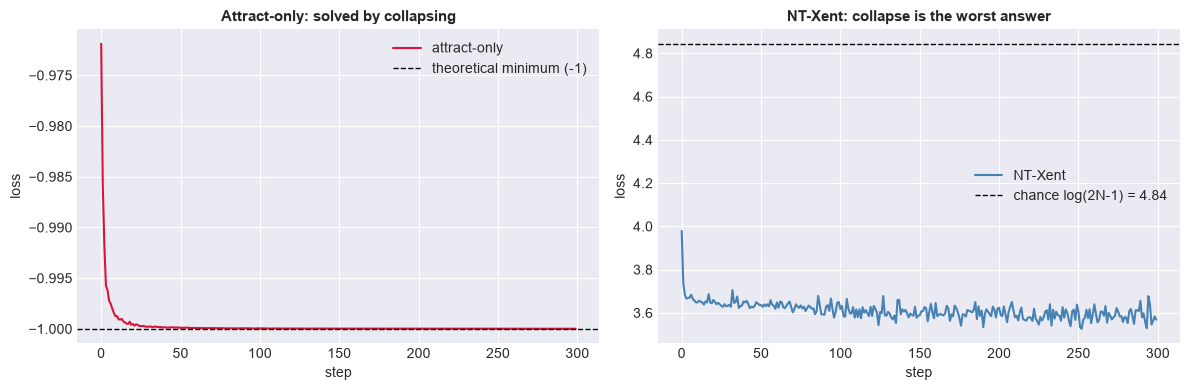

In [8]:
def attract_only_loss(z):
    z = F.normalize(z, dim=1)
    return -(z[0::2] * z[1::2]).sum(dim=1).mean()


def make_toy(n=256, d=8, k=4, seed=SEED):
    g = torch.Generator().manual_seed(seed)
    centers = torch.randn(k, d, generator=g) * 3.0
    lab = torch.randint(0, k, (n,), generator=g)
    return centers[lab] + torch.randn(n, d, generator=g) * 0.5, lab


class ToyEncoder(nn.Module):
    def __init__(self, d_in=8, d_h=32, d_out=8):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_in, d_h), nn.ReLU(), nn.Linear(d_h, d_out))

    def forward(self, x):
        return self.net(x)


def train_toy(objective, steps=300, tau=0.5, batch=64, seed=SEED):
    torch.manual_seed(seed)
    gen = torch.Generator().manual_seed(seed + 99)
    Xt, _ = make_toy(seed=seed)
    enc = ToyEncoder()
    opt = torch.optim.Adam(enc.parameters(), lr=1e-2)
    history = []
    for _ in range(steps):
        idx = torch.randperm(Xt.shape[0], generator=gen)[:batch]
        xb = Xt[idx]
        v1 = xb + torch.randn(xb.shape, generator=gen) * 0.5      # two noisy "views"
        v2 = xb + torch.randn(xb.shape, generator=gen) * 0.5
        z = torch.stack([enc(v1), enc(v2)], dim=1).reshape(2 * len(idx), -1)
        loss = attract_only_loss(z) if objective == 'attract' else nt_xent(z, tau)
        opt.zero_grad(); loss.backward(); opt.step()
        history.append(loss.item())
    with torch.no_grad():
        Zn = F.normalize(enc(Xt), dim=1)
        Zraw = enc(Xt)
    off_diag = (Zn @ Zn.t())[~torch.eye(Zn.shape[0], dtype=torch.bool)]
    return dict(history=history, final=history[-1],
                mean_pair_cos=off_diag.mean().item(),
                dim_std=Zn.std(dim=0).mean().item(),
                raw=Zraw, normed=Zn)


res_attract = train_toy('attract')
res_ntxent = train_toy('ntxent')
chance_toy = math.log(2 * 64 - 1)

print(f"{'objective':<14} {'final loss':>11} {'mean pairwise cos':>19} {'mean per-dim std':>18}")
print(f"{'attract-only':<14} {res_attract['final']:>11.6f} {res_attract['mean_pair_cos']:>19.6f} "
      f"{res_attract['dim_std']:>18.6f}")
print(f"{'NT-Xent':<14} {res_ntxent['final']:>11.6f} {res_ntxent['mean_pair_cos']:>19.6f} "
      f"{res_ntxent['dim_std']:>18.6f}")

print(f"\nAttract-only reached {res_attract['final']:.6f}, within {abs(res_attract['final'] + 1):.1e} of the "
      f"theoretical minimum of -1.0 -- and it got there by making every embedding the same direction "
      f"(mean pairwise cosine {res_attract['mean_pair_cos']:.4f}, per-dimension spread "
      f"{res_attract['dim_std']:.4f}). The objective is fully solved and the representation is empty.")
print(f"NT-Xent reached {res_ntxent['final']:.4f}, below the chance value log(2N-1) = {chance_toy:.4f}, "
      f"with mean pairwise cosine {res_ntxent['mean_pair_cos']:.4f} and per-dimension spread "
      f"{res_ntxent['dim_std']:.4f} -- "
      f"{res_ntxent['dim_std'] / max(res_attract['dim_std'], 1e-12):.0f}x the attract-only run's.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(res_attract['history'], label='attract-only', color='crimson')
axes[0].axhline(-1.0, ls='--', c='k', lw=1, label='theoretical minimum (-1)')
axes[0].set_xlabel('step'); axes[0].set_ylabel('loss')
axes[0].set_title('Attract-only: solved by collapsing', fontsize=11, fontweight='bold')
axes[0].legend()
axes[1].plot(res_ntxent['history'], label='NT-Xent', color='steelblue')
axes[1].axhline(chance_toy, ls='--', c='k', lw=1, label=f'chance log(2N-1) = {chance_toy:.2f}')
axes[1].set_xlabel('step'); axes[1].set_ylabel('loss')
axes[1].set_title('NT-Xent: collapse is the worst answer', fontsize=11, fontweight='bold')
axes[1].legend()
plt.tight_layout(); plt.show()

### BYOL and VICReg: removing the negatives without collapsing

Negatives are expensive -- the mutual-information ceiling $\log(2N-1)$ says you want a large batch, and a large batch of high-resolution images is a hardware problem. Two families answer it by dropping negatives and blocking collapse some other way. **Neither is implemented here** -- they are named so you know what exists and why, in the same spirit as Lesson 25A naming CBOW without building it; Lesson 26B's practical notebook stays with SimCLR.

**BYOL** (Grill et al., 2020, *Bootstrap Your Own Latent*) keeps only positive pairs and runs two asymmetric networks: an *online* network with an extra predictor MLP on top, and a *target* network whose weights are an exponential moving average of the online network's. The online branch regresses the target branch's projection; gradients never flow into the target (a stop-gradient). Collapse is not forbidden by the loss -- the constant solution still achieves the minimum -- but the update rule never converges to it, because the online network is chasing a moving target that it does not itself directly control. **SimSiam** (Chen & He, 2021) then showed the moving average is not even necessary: stop-gradient plus predictor is enough. That the mechanism works is uncontroversial; exactly *why* it works is still argued over, and it is worth being honest that no one-line explanation here would be trustworthy.

**VICReg** (Bardes, Ponce & LeCun, 2022) takes the opposite approach and forbids collapse explicitly, with three terms: an **invariance** term (the attract-only loss above), a **variance** term hinging each embedding dimension's standard deviation above a threshold $\gamma$, and a **covariance** term pushing off-diagonal covariances toward zero. The variance term penalises collapse directly; the covariance term additionally blocks **dimensional collapse** -- embeddings that keep plenty of spread but occupy a low-rank subspace.

Evaluate both terms on the two runs above as a diagnostic -- not a VICReg training run -- and something instructive goes wrong, which is why it is worth measuring rather than assuming. The naive expectation is "collapse drives the variance to zero, so the variance term catches it". Our collapsed encoder maximises **cosine** similarity, so it collapses in *direction* while leaving *magnitude* entirely free, and both of VICReg's terms are scale-dependent. Watch what each statistic actually reports.

In [9]:
GAMMA = 1.0   # VICReg's target per-dimension standard deviation


def variance_hinge(Z, gamma):
    'VICReg variance term: mean over dimensions of max(0, gamma - std_j). Zero means no penalty.'
    return torch.clamp(gamma - Z.std(dim=0), min=0.0).mean().item()


def covariance_term(Z):
    'VICReg covariance term: sum of squared OFF-diagonal covariances, divided by the dimension.'
    Zc = Z - Z.mean(dim=0, keepdim=True)
    C = (Zc.t() @ Zc) / (Z.shape[0] - 1)
    off = C - torch.diag(torch.diag(C))
    return (off.pow(2).sum() / Z.shape[1]).item()


def mean_abs_offdiag_correlation(Z):
    'Scale-free cousin of the covariance term: mean |correlation| over off-diagonal pairs.'
    Zc = Z - Z.mean(dim=0, keepdim=True)
    Zs = Zc / Zc.std(dim=0, keepdim=True).clamp_min(1e-9)
    R = (Zs.t() @ Zs) / (Z.shape[0] - 1)
    d = Z.shape[1]
    return ((R - torch.diag(torch.diag(R))).abs().sum() / (d * (d - 1))).item()


def effective_rank(Z):
    'exp(Shannon entropy of the normalised eigenvalue spectrum) -- how many dimensions are really used.'
    Zc = Z - Z.mean(dim=0, keepdim=True)
    p = torch.linalg.svdvals(Zc) ** 2
    p = p / p.sum()
    return float(torch.exp(-(p * p.clamp_min(1e-12).log()).sum()))


d_emb = res_attract['raw'].shape[1]
ceiling = 1.0 / math.sqrt(d_emb)     # max attainable mean per-dim std for unit-norm vectors

rows_vic = []
for name, r in [('attract-only', res_attract), ('NT-Xent', res_ntxent)]:
    Z = r['raw']
    rows_vic.append((name,
                     r['normed'].std(dim=0).mean().item(),      # scale-free
                     variance_hinge(Z, GAMMA),                  # scale-dependent
                     covariance_term(Z),                        # scale-dependent
                     mean_abs_offdiag_correlation(Z),           # scale-free
                     effective_rank(Z)))                        # scale-free

print(f"Embedding dimension d = {d_emb}. For unit-norm vectors the largest attainable mean per-dimension")
print(f"spread is 1/sqrt({d_emb}) = {ceiling:.4f}, so the first column is quoted against that ceiling.\n")
print(f"  {'run':<13} {'normed std':>11} {'(% ceiling)':>12} {'VICReg var':>11} {'VICReg cov':>11} "
      f"{'mean |corr|':>12} {'eff. rank':>10}")
for name, ns, vh, cv, mc, er in rows_vic:
    print(f"  {name:<13} {ns:>11.4f} {ns / ceiling:>12.1%} {vh:>11.4f} {cv:>11.4f} "
          f"{mc:>12.4f} {er:>10.2f}")
print(f"  {'':<13} {'scale-free':>11} {'':>12} {'SCALE-DEP':>11} {'SCALE-DEP':>11} "
      f"{'scale-free':>12} {'scale-free':>10}")

(_, ns_a, vh_a, cv_a, mc_a, er_a), (_, ns_n, vh_n, cv_n, mc_n, er_n) = rows_vic

print(f"\nEvery scale-free statistic agrees that the attract-only run collapsed: it uses "
      f"{ns_a / ceiling:.1%} of the attainable directional spread against {ns_n / ceiling:.1%}, its "
      f"dimensions are correlated {mc_a:.3f} against {mc_n:.3f}, and its effective rank is {er_a:.2f} "
      f"out of {d_emb} against {er_n:.2f}. An effective rank of {er_a:.2f} means the {d_emb}-dimensional "
      f"embedding is, to a good approximation, a line.")

cov_direction = "the RIGHT way" if cv_a > cv_n else "the WRONG way"
hinge_direction = "the RIGHT way" if vh_a > vh_n else "the WRONG way"
print(f"\nBoth of VICReg's own terms, read off these embeddings, are confounded by scale -- but NOT in the "
      f"same direction. The covariance term points {cov_direction} ({cv_a:.3f} for the collapsed run vs "
      f"{cv_n:.3f} for the healthy one): raw covariance scales with the SQUARE of the embedding's scale, "
      f"so the NT-Xent encoder's merely larger raw outputs ({rows_vic[1][0]}: per-dim std "
      f"{res_ntxent['raw'].std(dim=0).mean():.3f} vs {res_attract['raw'].std(dim=0).mean():.3f}) genuinely "
      f"INFLATE it, regardless of collapse. The variance hinge is the opposite story: hinge = "
      f"max(0, gamma - std), so a LARGER scale DEFLATES it -- it currently points {hinge_direction} "
      f"({vh_a:.4f} vs {vh_n:.4f}), but for the wrong reason, since a bigger std alone (not less collapse) "
      f"is what shrank it. Check this by removing the scale confound directly: rescale the NT-Xent "
      f"embeddings to match the attract-only run's own per-dimension scale, and watch the hinge.")

scale_match = res_attract['raw'].std(dim=0).mean().item() / res_ntxent['raw'].std(dim=0).mean().item()
print(f"\n  {'rescale factor':>15} {'ntxent per-dim std':>19} {'ntxent hinge':>13} {'vs attract':>12}")
for factor in [0.25, 0.5, round(scale_match, 3), 1.0, 2.0, 4.0]:
    Zs = res_ntxent['raw'] * factor
    vh_s = variance_hinge(Zs, GAMMA)
    tag = "matched scale" if abs(factor - scale_match) < 1e-6 else ""
    print(f"  {factor:>15} {Zs.std(dim=0).mean().item():>19.4f} {vh_s:>13.4f} "
          f"{'higher than attract' if vh_s > vh_a else 'lower than attract':>12}  {tag}")
vh_matched = variance_hinge(res_ntxent['raw'] * scale_match, GAMMA)
matched_direction = "the RIGHT way" if vh_a > vh_matched else "the WRONG way"  # right = collapsed (attract) still reads the higher hinge
print(f"\nAt matched scale the hinge reads {vh_matched:.4f} against the collapsed run's {vh_a:.4f} -- "
      f"pointing {matched_direction}. The apparent {vh_a / max(vh_n, 1e-12):.1f}x separation at native "
      f"scale was a scale artefact, not a genuine detection of collapse: once scale is controlled for, "
      f"BOTH of VICReg's raw-embedding terms are unreliable here, not just the covariance term. Neither "
      f"is a defect in VICReg -- both terms are defined on UN-NORMALISED embeddings, and this course's "
      f"attract-only objective maximised COSINE similarity, which collapses direction while leaving "
      f"magnitude free -- exactly the geometry these two terms were never designed to be read in.")
print(f"\nThe transferable lesson is about diagnostics, not about VICReg: measure collapse in the geometry "
      f"your loss actually uses. If the loss normalises, so must the monitor -- mean pairwise cosine, "
      f"normalised per-dimension spread, or effective rank. A scale-dependent metric lifted out of its "
      f"home geometry is how a collapse monitor quietly stops monitoring.")

Embedding dimension d = 8. For unit-norm vectors the largest attainable mean per-dimension
spread is 1/sqrt(8) = 0.3536, so the first column is quoted against that ceiling.

  run            normed std  (% ceiling)  VICReg var  VICReg cov  mean |corr|  eff. rank
  attract-only       0.0272         7.7%      0.2026      2.0772       0.7717       1.63
  NT-Xent            0.3359        95.0%      0.1036      5.9808       0.3179       3.60
                 scale-free                SCALE-DEP   SCALE-DEP   scale-free scale-free

Every scale-free statistic agrees that the attract-only run collapsed: it uses 7.7% of the attainable directional spread against 95.0%, its dimensions are correlated 0.772 against 0.318, and its effective rank is 1.63 out of 8 against 3.60. An effective rank of 1.63 means the 8-dimensional embedding is, to a good approximation, a line.

Both of VICReg's own terms, read off these embeddings, are confounded by scale -- but NOT in the same direction. The covariance te

<a name="augmentations"></a>
## Augmentations as the Specification of Invariance

The loss says "two views of the same image must be close". It says nothing about which views. **The augmentation distribution is therefore the entire specification of what the representation is allowed to ignore**, and choosing it is a modelling decision about the domain -- not a preprocessing detail, and not transferable between domains by copying a published recipe.

Read the standard SimCLR augmentations as statements:

| Augmentation | The invariance it demands | The assumption it encodes |
|---|---|---|
| random crop + resize | position and scale are irrelevant | the object is identifiable from a part of it |
| horizontal flip | left-right orientation is irrelevant | the class is chirality-free |
| colour jitter / greyscale | hue and saturation are irrelevant | shape carries the class, colour does not |
| Gaussian blur | fine texture is irrelevant | the class survives low-pass filtering |
| additive pixel noise | small per-pixel perturbations are irrelevant | the class is robust to sensor noise |
| small rotation | pose within a few degrees is irrelevant | the object has no canonical up to within that range |

SimCLR's ablations found random cropping plus colour distortion to be the pair that matters most on ImageNet -- and specifically that cropping *alone* is defeated by a shortcut, because two crops of the same photo share a colour histogram that identifies the source image without any understanding of its content. Colour jitter exists to close that shortcut. **A contrastive model will always solve the puzzle the cheapest way the augmentations permit**, which is why the augmentation set is where the thinking goes.

Digits are a domain where a copied recipe fails outright, and it is cheap to measure rather than argue. An augmentation is safe only if the augmented image is still "the same thing" for the downstream task. A quick proxy for that: augment a held-out image, find its nearest neighbour in pixel space among a reference set, and check whether the neighbour's class still matches. A label-preserving augmentation should barely move the number; a label-destroying one should wreck it. (Pixel-space nearest neighbour is a cheap screen, not the downstream task -- it is evidence, not proof.)

1-NN class preservation over 800 queries against a 4000-image reference set
(higher = the augmentation left the digit recognisable in pixel space)

  identity (control)           0.934   #####################################
  gaussian noise               0.936   #####################################
  rotate +/-15 deg             0.916   #####################################
  crop + resize                0.856   ##################################
  SimCLR stack (used below)    0.826   #################################
  horizontal flip              0.433   #################
  vertical flip                0.327   #############

The un-augmented control sits at 0.934. That is the reference level, fixed by how good pixel-space 1-NN is on MNIST at all rather than by any augmentation -- and it is a reference, not a ceiling: 2 augmentations land within 0.02 of it (gaussian noise, rotate +/-15 deg), which over 800 queries is at most 16 changed decisions. Read those as indistinguishable from

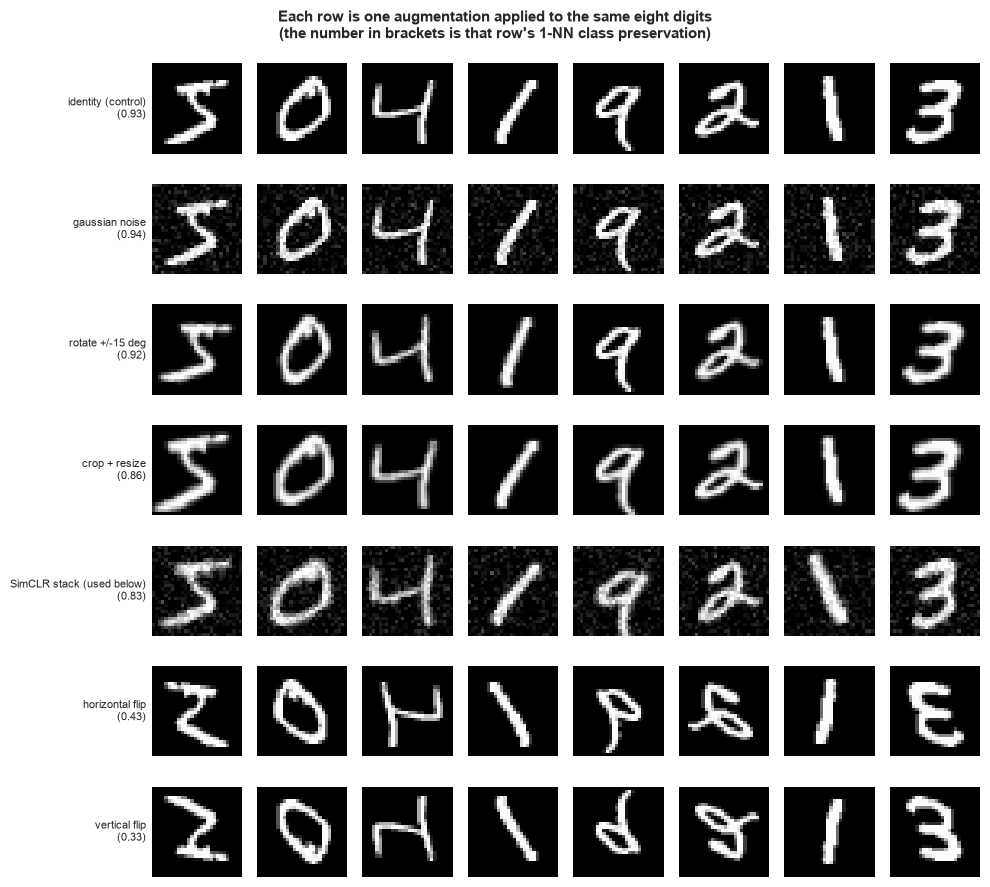

In [10]:
def _affine_apply(x, theta):
    grid = F.affine_grid(theta, x.shape, align_corners=False)
    return F.grid_sample(x, grid, align_corners=False, padding_mode='zeros')


def rand_crop_resize(x, gen, area_min=0.7, area_max=1.0):
    'Random crop of a fraction of the area, resized back to 28x28, via one affine warp.'
    b = x.shape[0]
    s = (torch.rand(b, generator=gen) * (area_max - area_min) + area_min).sqrt()   # linear scale
    tx = (1 - s) * (torch.rand(b, generator=gen) * 2 - 1)
    ty = (1 - s) * (torch.rand(b, generator=gen) * 2 - 1)
    th = torch.zeros(b, 2, 3)
    th[:, 0, 0] = s; th[:, 1, 1] = s; th[:, 0, 2] = tx; th[:, 1, 2] = ty
    return _affine_apply(x, th)


def rand_rotate(x, gen, max_deg=15.0):
    b = x.shape[0]
    a = (torch.rand(b, generator=gen) * 2 - 1) * math.radians(max_deg)
    th = torch.zeros(b, 2, 3)
    th[:, 0, 0] = torch.cos(a); th[:, 0, 1] = -torch.sin(a)
    th[:, 1, 0] = torch.sin(a); th[:, 1, 1] = torch.cos(a)
    return _affine_apply(x, th)


def add_noise(x, gen, sigma=0.10):
    return (x + torch.randn(x.shape, generator=gen) * sigma).clamp(0, 1)


def hflip(x, gen=None):
    return torch.flip(x, dims=[3])


def vflip(x, gen=None):
    return torch.flip(x, dims=[2])


def simclr_view(x, gen):
    'The augmentation stack used for the end-to-end run below.'
    return add_noise(rand_rotate(rand_crop_resize(x, gen), gen), gen)


AUGS = {
    'identity (control)': lambda x, g: x,
    'gaussian noise': add_noise,
    'rotate +/-15 deg': rand_rotate,
    'crop + resize': rand_crop_resize,
    'SimCLR stack (used below)': simclr_view,
    'horizontal flip': hflip,
    'vertical flip': vflip,
}

N_REF, N_QUERY = 4000, 800
ref_flat, ref_lab = flat[:N_REF], y_true[:N_REF]
q_slice = torch.arange(N_REF, N_REF + N_QUERY)
q_lab = y_true[q_slice]


def nn_class_preserved(aug_fn, gen):
    q = aug_fn(X_img[q_slice], gen).reshape(N_QUERY, -1)
    nn_lab = ref_lab[torch.cdist(q, ref_flat).argmin(dim=1)]
    return (nn_lab == q_lab).float().mean().item()


gen_aug = torch.Generator().manual_seed(SEED)
preservation = {name: nn_class_preserved(fn, gen_aug) for name, fn in AUGS.items()}

print(f"1-NN class preservation over {N_QUERY} queries against a {N_REF}-image reference set")
print(f"(higher = the augmentation left the digit recognisable in pixel space)\n")
for name, val in preservation.items():
    print(f"  {name:<28} {val:.3f}   {'#' * int(round(val * 40))}")

TOL = 0.02          # ~16 of the 800 nearest-neighbour decisions; anything inside this is a tie
ctrl = preservation['identity (control)']
flips = ['horizontal flip', 'vertical flip']
best_flip = max(preservation[f] for f in flips)
non_flip = {k: v for k, v in preservation.items() if k not in flips and k != 'identity (control)'}
worst_non_flip = min(non_flip, key=non_flip.get)
ties = [k for k, v in preservation.items() if k != 'identity (control)' and abs(v - ctrl) <= TOL]

print(f"\nThe un-augmented control sits at {ctrl:.3f}. That is the reference level, fixed by how good "
      f"pixel-space 1-NN is on MNIST at all rather than by any augmentation -- and it is a reference, "
      f"not a ceiling: {len(ties)} augmentation{'' if len(ties) == 1 else 's'} land within {TOL:.2f} of it "
      f"({', '.join(ties) if ties else 'none'}), which over {N_QUERY} queries is at most "
      f"{int(round(TOL * N_QUERY))} changed decisions. Read those as indistinguishable from doing "
      f"nothing, in either direction.")
print(f"Both flips fall far below every non-flip augmentation: the better of the two reaches only "
      f"{best_flip:.3f}, against {non_flip[worst_non_flip]:.3f} for the weakest non-flip "
      f"('{worst_non_flip}'), a gap of {non_flip[worst_non_flip] - best_flip:.3f}.")

ranked = sorted(preservation.items(), key=lambda kv: kv[1])
if ranked[1][1] - ranked[0][1] <= TOL:
    tied_worst = [k for k, v in ranked if v - ranked[0][1] <= TOL]
    print(f"The most destructive result is a tie within {TOL:.2f}: {', '.join(tied_worst)} "
          f"(scores {', '.join(f'{preservation[k]:.3f}' for k in tied_worst)}).")
else:
    print(f"'{ranked[0][0]}' is the single most destructive at {ranked[0][1]:.3f}, clear of the next "
          f"worst ('{ranked[1][0]}', {ranked[1][1]:.3f}) by {ranked[1][1] - ranked[0][1]:.3f}.")
print(f"\nHorizontal flip is in SimCLR's published recipe because a mirrored cat is still a cat. "
      f"A mirrored 2 is not a 2. Demanding flip-invariance here would instruct the encoder to erase "
      f"exactly the information the downstream task needs -- the recipe does not transfer, and the "
      f"table above is how you find that out in a few seconds rather than after a training run.")

fig, axes = plt.subplots(len(AUGS), 8, figsize=(10, 1.3 * len(AUGS)))
gen_show = torch.Generator().manual_seed(SEED)
for r, (name, fn) in enumerate(AUGS.items()):
    shown = fn(X_img[:8], gen_show)
    for c in range(8):
        ax = axes[r, c]
        ax.imshow(shown[c, 0], cmap='gray', vmin=0, vmax=1)
        ax.set_xticks([]); ax.set_yticks([])
        for side in ax.spines.values():
            side.set_visible(False)
    axes[r, 0].set_ylabel(f"{name}\n({preservation[name]:.2f})",
                          rotation=0, ha='right', va='center', fontsize=8)
plt.suptitle('Each row is one augmentation applied to the same eight digits\n'
             '(the number in brackets is that row\'s 1-NN class preservation)',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

<a name="mnist-run"></a>
## End-to-End: SimCLR on an MNIST Subset

Everything above assembled: the encoder from component 2, the projection head from component 3, the augmentation stack whose invariances we just audited, and NT-Xent as the loss. Deliberately small -- a 3-layer CNN, a 64-dimensional representation, a 32-dimensional projection, and a few thousand images -- so it finishes quickly on CPU and can be re-run in Colab. The measured wall time is printed with the results rather than asserted here.

**No label is used anywhere in training.** The labels enter only after the fact -- to colour the t-SNE plot and to compute the separation diagnostics. If you deleted them entirely the training loop below would be unchanged, which is the whole point of the exercise. (Lesson 16 made the complementary move -- keeping a *handful* of labels and propagating them through the unlabelled data's structure with label propagation and self-training. A linear probe on frozen contrastive features, which Lesson 26B builds, is the same bargain from the other side: learn the structure with no labels at all, then spend a few labels only on the final read-out.)

Trained 60 epochs on 6000 unlabelled images (batch 256, tau 0.5, 1380 steps) in 194.4s of CPU.
NT-Xent: 5.4887 (epoch 1) -> 4.4136 (epoch 60), a fall of 1.0751 nats.
Chance level for this batch size is log(2N-1) = 6.2364; the final loss sits 1.8228 nats below it, so the certified mutual-information bound log M - L is 1.8228 nats against a ceiling of 6.2364.
Read that bound with one caveat: it assumes the negatives are independent draws from the marginal, and NT-Xent's are not quite -- the two views of any other image are correlated with each other. The number is the bound evaluated as if they were, which is the usual convention.
Third-quarter mean 4.4263, fourth-quarter mean 4.4140: a further fall of 0.0123 nats against a largest single-epoch RISE of 0.0040 within the same half, so the curve is still descending faster than it wobbles. The last three epochs read 4.4098, 4.4138, 4.4136.


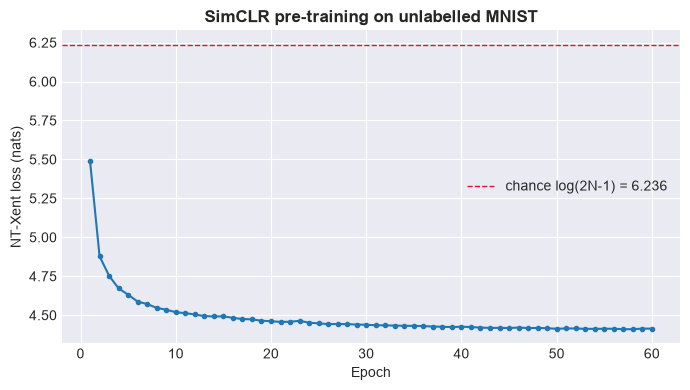

In [11]:
class SimCLRNet(nn.Module):
    'Small CNN encoder (kept) + MLP projection head (discarded after training).'

    def __init__(self, rep_dim=64, proj_dim=32):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.ReLU(),     # 28 -> 14
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(),    # 14 -> 7
            nn.Conv2d(64, 64, 3, stride=2, padding=1), nn.ReLU(),    # 7  -> 4
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, rep_dim), nn.ReLU(),
        )
        self.head = nn.Sequential(
            nn.Linear(rep_dim, rep_dim), nn.ReLU(),
            nn.Linear(rep_dim, proj_dim),
        )

    def forward(self, x):
        h = self.backbone(x)          # representation -- this is what you keep
        return h, self.head(h)        # projection -- this is what the loss sees


EPOCHS, BATCH, TAU, LR = 60, 256, 0.5, 0.003

torch.manual_seed(SEED)
model = SimCLRNet()
untrained = SimCLRNet()               # same seed, same init: the control
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
n_steps = EPOCHS * (N_IMAGES // BATCH)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_steps)
gen_train = torch.Generator().manual_seed(SEED)

epoch_losses = []
t_start = time.time()
for epoch in range(EPOCHS):
    perm = torch.randperm(N_IMAGES, generator=gen_train)
    running, seen = 0.0, 0
    for start in range(0, N_IMAGES - BATCH + 1, BATCH):
        xb = X_img[perm[start:start + BATCH]]
        _, z1 = model(simclr_view(xb, gen_train))
        _, z2 = model(simclr_view(xb, gen_train))
        z = torch.stack([z1, z2], dim=1).reshape(2 * BATCH, -1)   # interleave the pairs
        loss = nt_xent(z, TAU)
        optimizer.zero_grad(); loss.backward(); optimizer.step(); scheduler.step()
        running += loss.item() * BATCH; seen += BATCH
    epoch_losses.append(running / seen)
train_seconds = time.time() - t_start

chance_level = math.log(2 * BATCH - 1)
print(f"Trained {EPOCHS} epochs on {N_IMAGES} unlabelled images "
      f"(batch {BATCH}, tau {TAU}, {n_steps} steps) in {train_seconds:.1f}s of CPU.")
print(f"NT-Xent: {epoch_losses[0]:.4f} (epoch 1) -> {epoch_losses[-1]:.4f} (epoch {EPOCHS}), "
      f"a fall of {epoch_losses[0] - epoch_losses[-1]:.4f} nats.")
print(f"Chance level for this batch size is log(2N-1) = {chance_level:.4f}; the final loss sits "
      f"{chance_level - epoch_losses[-1]:.4f} nats below it, so the certified mutual-information "
      f"bound log M - L is {chance_level - epoch_losses[-1]:.4f} nats "
      f"against a ceiling of {chance_level:.4f}.")
print("Read that bound with one caveat: it assumes the negatives are independent draws from the "
      "marginal, and NT-Xent's are not quite -- the two views of any other image are correlated with "
      "each other. The number is the bound evaluated as if they were, which is the usual convention.")
q3 = float(np.mean(epoch_losses[EPOCHS // 2:3 * EPOCHS // 4]))
q4 = float(np.mean(epoch_losses[3 * EPOCHS // 4:]))
second_half = epoch_losses[EPOCHS // 2:]
max_rise = max((b - a for a, b in zip(second_half, second_half[1:])), default=0.0)
still_falling = (q3 - q4) > max_rise
print(f"Third-quarter mean {q3:.4f}, fourth-quarter mean {q4:.4f}: a further fall of {q3 - q4:.4f} nats "
      f"against a largest single-epoch RISE of {max_rise:.4f} within the same half, so the curve is "
      f"{'still descending faster than it wobbles' if still_falling else 'flat at the scale of its own noise'}. "
      f"The last three epochs read {', '.join(f'{v:.4f}' for v in epoch_losses[-3:])}.")

plt.figure(figsize=(7, 4))
plt.plot(range(1, EPOCHS + 1), epoch_losses, marker='o', ms=3)
plt.axhline(chance_level, ls='--', c='crimson', lw=1,
            label=f'chance log(2N-1) = {chance_level:.3f}')
plt.xlabel('Epoch'); plt.ylabel('NT-Xent loss (nats)')
plt.title('SimCLR pre-training on unlabelled MNIST', fontsize=12, fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()

### Reading the representation

Two diagnostics and one plot, all computed on the **representation** $h$ (the backbone's 64-dimensional output) rather than the projection $z$, per SimCLR's own finding that $h$ is the better transfer feature.

- **Silhouette score** against the true digit labels: how tightly each class clusters relative to its nearest neighbouring class.
- **5-NN accuracy** under 3-fold cross-validation: whether the class is locally decodable from the features.
- **A t-SNE map** (Lesson 6A) coloured by the held-out label.

Two controls make the numbers mean something. The first is an **untrained network with the identical architecture and the same random initialisation** -- any gain over that is attributable to the objective rather than to the convolutional inductive bias. The second is **raw pixels**, which on MNIST are an unusually strong nearest-neighbour baseline and should be treated as a real competitor, not a straw man.

One caveat carried forward from Lesson 6A, which derived t-SNE and then spent a section on its artifacts: t-SNE optimises a local-neighbourhood criterion, so **cluster sizes and between-cluster distances in the map are not meaningful, and apparent clusters can be manufactured by the algorithm itself**. The map below is a hypothesis-generating picture. The silhouette score, computed in the original 64-dimensional feature space rather than on the 2-D map, is the number to trust.

t-SNE of the 64-d representation took 10.7s.

features                             dims   silhouette   5-NN acc (3-fold)
SimCLR representation (64-d)           64       0.1470              0.9302
untrained CNN, same init (64-d)        64      -0.0037              0.7518
raw pixels (784-d)                    784       0.0482              0.9270

(Both diagnostics use the held-out digit labels; the training loop never did.)

Against the untrained control -- identical architecture and initialisation, no training -- silhouette moves -0.0037 -> +0.1470, an absolute gain of 0.1507; no ratio is quoted because the control's score is NEGATIVE, which means its classes sit on average closer to a neighbouring class than to their own, and 5-NN accuracy rises 0.752 -> 0.930. The gain is from the objective, not the architecture.
Against raw pixels the representation is level (0.930 vs 0.927, a gap of +0.003 -- too small to call a win either way) on 5-NN accuracy, while using 12x fewer dimensions, and

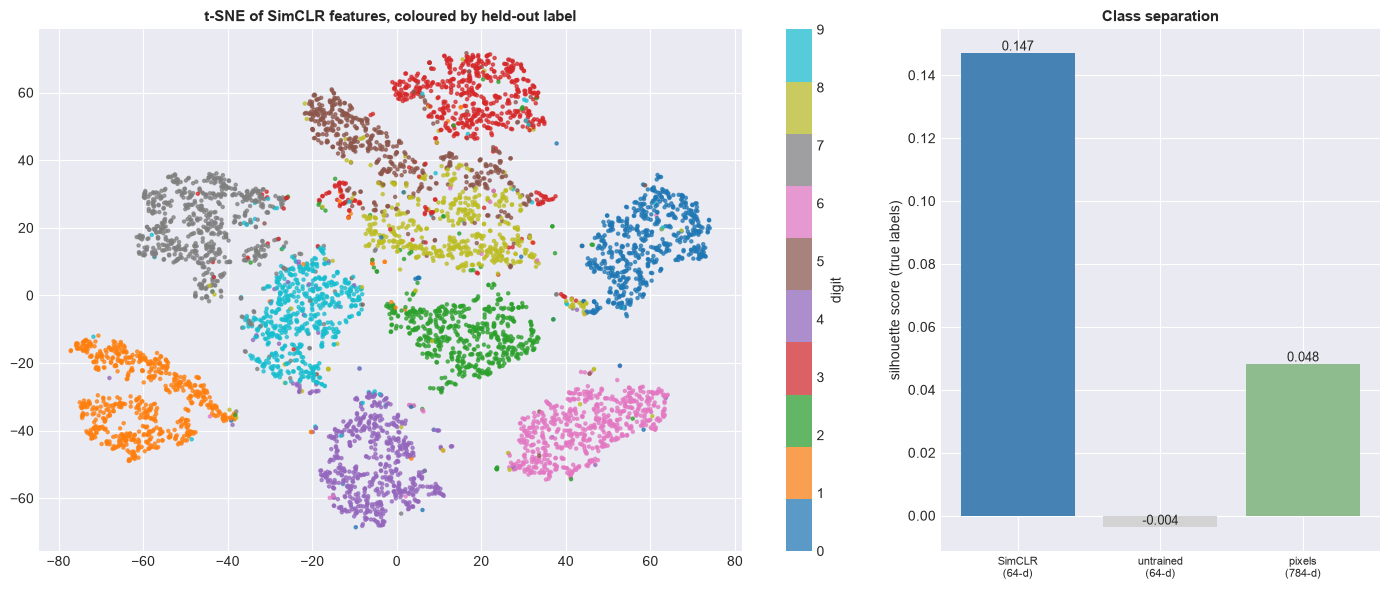

In [12]:
with torch.no_grad():
    H_trained, _ = model(X_img)
    H_untrained, _ = untrained(X_img)
H_trained = H_trained.numpy()
H_untrained = H_untrained.numpy()
X_pixels = flat.numpy()
labels_np = y_true.numpy()

t0 = time.time()
emb2d = TSNE(n_components=2, perplexity=30, init='pca', random_state=SEED).fit_transform(H_trained)
tsne_seconds = time.time() - t0

feature_sets = [
    ('SimCLR representation (64-d)', H_trained),
    ('untrained CNN, same init (64-d)', H_untrained),
    ('raw pixels (784-d)', X_pixels),
]
sil = {name: silhouette_score(F_, labels_np) for name, F_ in feature_sets}
knn = {name: cross_val_score(KNeighborsClassifier(5), F_, labels_np, cv=3).mean()
       for name, F_ in feature_sets}

print(f"t-SNE of the 64-d representation took {tsne_seconds:.1f}s.\n")
print(f"{'features':<34} {'dims':>6} {'silhouette':>12} {'5-NN acc (3-fold)':>19}")
for name, F_ in feature_sets:
    print(f"{name:<34} {F_.shape[1]:>6} {sil[name]:>12.4f} {knn[name]:>19.4f}")
print("\n(Both diagnostics use the held-out digit labels; the training loop never did.)")

sil_tr = sil['SimCLR representation (64-d)']
sil_un = sil['untrained CNN, same init (64-d)']
sil_px = sil['raw pixels (784-d)']
knn_tr = knn['SimCLR representation (64-d)']
knn_un = knn['untrained CNN, same init (64-d)']
knn_px = knn['raw pixels (784-d)']

if sil_un <= 0:
    sil_phrase = (f"silhouette moves {sil_un:+.4f} -> {sil_tr:+.4f}, an absolute gain of "
                  f"{sil_tr - sil_un:.4f}; no ratio is quoted because the control's score is NEGATIVE, "
                  f"which means its classes sit on average closer to a neighbouring class than to their own")
else:
    sil_phrase = f"silhouette rises {sil_un:.4f} -> {sil_tr:.4f} ({sil_tr / sil_un:.1f}x)"
print(f"\nAgainst the untrained control -- identical architecture and initialisation, no training -- "
      f"{sil_phrase}, and 5-NN accuracy rises {knn_un:.3f} -> {knn_tr:.3f}. "
      f"The gain is from the objective, not the architecture.")

knn_gap = knn_tr - knn_px
if abs(knn_gap) < 0.01:
    knn_verdict = (f"is level ({knn_tr:.3f} vs {knn_px:.3f}, a gap of {knn_gap:+.3f} -- too small "
                   f"to call a win either way)")
elif knn_gap > 0:
    knn_verdict = f"beats raw pixels ({knn_tr:.3f} vs {knn_px:.3f}, {knn_gap:+.3f})"
else:
    knn_verdict = f"trails raw pixels ({knn_tr:.3f} vs {knn_px:.3f}, {knn_gap:+.3f})"
print(f"Against raw pixels the representation {knn_verdict} on 5-NN accuracy, while using "
      f"{X_pixels.shape[1] // H_trained.shape[1]}x fewer dimensions, and separates the classes "
      f"{sil_tr / sil_px:.1f}x better by silhouette ({sil_tr:.4f} vs {sil_px:.4f}). "
      f"Raw-pixel 1-NN on MNIST is a famously strong baseline, so matching it from a "
      f"{train_seconds:.0f}-second unsupervised run at {H_trained.shape[1]} dimensions is the "
      f"result worth reading here -- not a claim to have beaten it.")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [2, 1]})
sc = axes[0].scatter(emb2d[:, 0], emb2d[:, 1], c=labels_np, cmap='tab10', s=5, alpha=0.7)
axes[0].set_title('t-SNE of SimCLR features, coloured by held-out label', fontsize=11, fontweight='bold')
plt.colorbar(sc, ax=axes[0], label='digit', ticks=range(10))

short = ['SimCLR\n(64-d)', 'untrained\n(64-d)', 'pixels\n(784-d)']
axes[1].bar(short, [sil[n] for n, _ in feature_sets],
            color=['steelblue', 'lightgrey', 'darkseagreen'])
for i, n in enumerate([n for n, _ in feature_sets]):
    axes[1].text(i, sil[n], f'{sil[n]:.3f}', ha='center', va='bottom', fontsize=9)
axes[1].set_ylabel('silhouette score (true labels)')
axes[1].set_title('Class separation', fontsize=11, fontweight='bold')
axes[1].tick_params(axis='x', labelsize=8)
plt.tight_layout(); plt.show()

<a name="conclusion"></a>
## Conclusion

### Key Takeaways

1. **Pixel distance cannot express sameness, which is why reconstruction is not the only route to a representation.** Measured directly on MNIST: a 2-pixel shift of one image moves it farther in pixel space than a different image of the same digit does, for a large fraction of probes. Lesson 12A's autoencoder and Lesson 5's PCA both optimise a pixel-space criterion and inherit that blind spot; contrastive learning changes the criterion rather than the model.
2. **The contrastive game's Bayes-optimal solution depends on the data only through a density ratio, up to scale** -- verified exactly by evaluating the posterior in its original product form and in the collapsed ratio form and finding them identical. That is what licenses an unnormalised similarity score as a critic.
3. **InfoNCE lower-bounds mutual information, and the bound is capped at $\log M$.** Verified numerically against a joint distribution whose mutual information is known in closed form: the bound held at every candidate count, tightened monotonically as $M$ grew, and at the smallest $M$ the ceiling $\log M$ was itself below the true mutual information -- so no critic, however good, could have certified the truth there. Certifying $I$ nats needs $M \ge e^{I}$ candidates.
4. **NT-Xent is that objective applied to a batch of augmented views, and the from-scratch implementation is right** -- it matches a closed-form hand-computed value $\log(1 + 2/e)$ and an independently structured plain-Python reference to float32 round-off, and it reproduces the exact collapse value $\log(2N-1)$ at every batch size and temperature tested.
5. **Temperature is the critic's dynamic range, not a tuning nuisance.** Low $\tau$ measurably sharpens the softmax onto the hardest negatives and scales the gradient by $1/\tau$; the same sharpening makes a single ambiguous pair dominate the batch, which the two-regime sweep above shows by driving the loss up sharply when a hard negative outranks the positive.
6. **Without negatives the objective's global optimum is a constant encoder.** Trained on purpose: the attract-only run reached the theoretical minimum of $-1$ and got there by mapping everything to one direction (mean pairwise cosine $\approx 1$, effective rank under 2 out of 8). NT-Xent makes that same configuration its *worst* case, at exactly $\log(2N-1)$.
7. **A collapse monitor must live in the same geometry as the loss.** Reading VICReg's variance and covariance terms -- both defined on un-normalised embeddings -- off our cosine-trained encoders separated the collapsed run from the healthy one only weakly in one case and in the *wrong direction* in the other, because a cosine collapse leaves magnitude free. Scale-free statistics got it right every time.
8. **The augmentation set is the specification of invariance, and it does not transfer between domains.** Horizontal flip is in SimCLR's published ImageNet recipe and is catastrophic on digits -- measured here as a large drop in 1-NN class preservation relative to every non-flip augmentation.
9. **A single, CPU-only, sub-3-minute training run (per this course's own house budget) on 6,000 unlabelled images produces features that match raw pixels on nearest-neighbour accuracy at a fraction of the dimensionality, with markedly better class separation** -- and beat an identically-initialised untrained CNN by a wide margin on both, which is the comparison that isolates the objective's contribution from the architecture's. (Wall-clock time varies with machine load -- the notebook's own printed seconds are the number to trust on any given run, not a fixed claim here.)

### Practical Guidance

- **Budget negatives before anything else.** The $\log M$ ceiling is a hard information limit, not a soft preference. If a large batch is unaffordable, use a memory queue (MoCo) rather than accepting a small $M$ and blaming the encoder.
- **Choose augmentations by asking what the downstream task must ignore**, then verify cheaply that they preserve the label -- a nearest-neighbour class-preservation screen costs seconds and catches a copied-recipe mistake before a training run does.
- **Watch for collapse explicitly, and monitor it in the geometry your loss uses.** Log mean pairwise cosine similarity, normalised per-dimension spread, or effective rank every epoch. A falling loss tells you nothing; a mean pairwise cosine heading for 1.0 tells you everything. The measurement above is the cautionary case: two scale-dependent statistics applied to cosine-trained embeddings separated a collapsed run from a healthy one weakly in one case and *backwards* in the other, while every scale-free statistic was unambiguous.
- **Keep the representation, discard the projection head.** Evaluate on $h$, not on $z$. The head exists so the invariances the loss demands do not have to be burned into the representation you actually use.
- **Do not read the InfoNCE loss as a quality score across settings.** It depends on $M$ and $\tau$; a run with a smaller batch has a lower chance level and its loss is not comparable. Compare $\log M - \mathcal{L}$, or better, compare downstream probe accuracy.

### What This Lesson Did Not Cover

- **BYOL, SimSiam and VICReg were named but not built.** They are the main non-contrastive answer to the collapse problem and each deserves its own derivation; here they appear conceptually, with VICReg's two regularisers evaluated only as post-hoc statistics on our toy runs. That evaluation is deliberately *not* a verdict on VICReg -- a term read outside the geometry it was designed for tells you about the mismatch, not about the method.
- **MoCo's momentum encoder and memory queue** -- the standard engineering answer to the $\log M$ ceiling -- are described in the guidance above and not implemented.
- **Colour augmentations**, which SimCLR's own ablation found essential on natural images precisely because they close the colour-histogram shortcut, are meaningless on single-channel MNIST and so are discussed but never applied.
- **A linear probe.** This notebook measures the representation with silhouette scores and $k$-NN, both of which are unsupervised-friendly diagnostics. The standard self-supervised evaluation -- freeze the encoder, train a linear classifier on top, report accuracy -- is Lesson 26B's job, along with the comparison against PCA (Lesson 5) and autoencoder (Lesson 12) features on the same data.
- **Any claim that these features are good in absolute terms.** MNIST at this scale is a demonstration, not a benchmark; raw pixels remain a strong baseline here and the honest reading is a tie on $k$-NN with a large win on compactness and separation.

### Next Steps

Lesson 26B takes this notebook's from-scratch NT-Xent and encoder into a production-shaped SimCLR pipeline, adds the **linear probe** that is the field's standard evaluation, and runs the three-way comparison this lesson has been building toward: contrastive features against **PCA** components (Lesson 5) and **autoencoder** codes (Lesson 12) under one identical probe, plus $k$-NN and 2D visualisations of all three -- with the visualisation caveats from **Lesson 6**'s manifold-learning notebook (t-SNE and UMAP can manufacture apparent clusters, so cluster structure in a 2D plot is a hypothesis, not a finding) applying to every embedding plot in both notebooks. It closes with ablations over temperature, the number of negatives, and the augmentation set -- turning each of this lesson's derived claims into a measured curve.